# Inception V3 Transfer Learning Flowers Corrected Dataset

In [1]:
#!pip install tensorflow matplotlib split-folders -q

In [ ]:
#!nbidia ...

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [6]:
#  Download and unzip dataset
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!mkdir -p ./flowers_dataset
!tar -xvzf flower_photos.tgz -C ./flowers_dataset

--2026-08-11 16:43:45--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.250.141.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M  75.3MB/s    in 2.9s    

2026-08-11 16:43:48 (75.3 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]

flower_photos/
flower_photos/roses/
flower_photos/roses/14810868100_87eb739f26_m.jpg
flower_photos/roses/1446090416_f0cad5fde4.jpg
flower_photos/roses/15319767030_e6c5602a77_m.jpg
flower_photos/roses/15032112248_30c5284e54_n.jpg
flower_photos/roses/7211616670_2d49ecb3a5_m.jpg
flower_photos/roses/15674450867_0ced942941_n.jpg
flower_photos/roses/17158274118_00ec99a23c.jpg
flow

In [7]:
# Split Flowers
import splitfolders
splitfolders.ratio("./flowers_dataset/flower_photos", output="./flowers_split", seed=42, ratio=(.7, .2, .1))

Copying files: 3670 files [00:01, 2971.67 files/s]


In [8]:
from numpy._core.fromnumeric import shape
from IPython.core.display import Image
IMG_SIZE = (299, 299)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=30, zoom_range=0.2,
                                   horizontal_flip=True)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory("./flowers_split/train",
                                                 target_size=IMG_SIZE,
                                                 batch_size=BATCH_SIZE,
                                                 class_mode='categorical')
val_generator = val_datagen.flow_from_directory("./flowers_split/val",
                                                 target_size=IMG_SIZE,
                                                 batch_size=BATCH_SIZE,
                                                 class_mode='categorical')
test_generator = test_datagen.flow_from_directory("./flowers_split/test",
                                                 target_size=IMG_SIZE,
                                                 batch_size=BATCH_SIZE,
                                                 class_mode='categorical', shuffle=False)



Found 2567 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Found 372 images belonging to 5 classes.


In [9]:
# Load InceptionV3 and add custom layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
for layer in base_model.layers:
  layer.trainable = False

x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,906,085 (91.19 MB)

 Trainable params: 2,103,301 (8.02 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [10]:
history = model.fit(train_generator, epochs = 10, validation_data = val_generator)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.6954 - loss: 0.8573 - val_accuracy: 0.8112 - val_loss: 0.5343
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8559 - loss: 0.4569 - val_accuracy: 0.8454 - val_loss: 0.4285
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8808 - loss: 0.3765 - val_accuracy: 0.8509 - val_loss: 0.3892
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.8933 - loss: 0.3208 - val_accuracy: 0.8782 - val_loss: 0.3412
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.8999 - loss: 0.2956 - val_accuracy: 0.8837 - val_loss: 0.3262
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9151 - loss: 0.2700 - val_accuracy: 0.8618 - val_loss: 0.3600
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.9162 - loss: 0.2553 - val_accuracy: 0.8960 - val_loss: 0.3130
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.9299 - loss: 0.2224 - val_accuracy: 0.8960 - val_loss

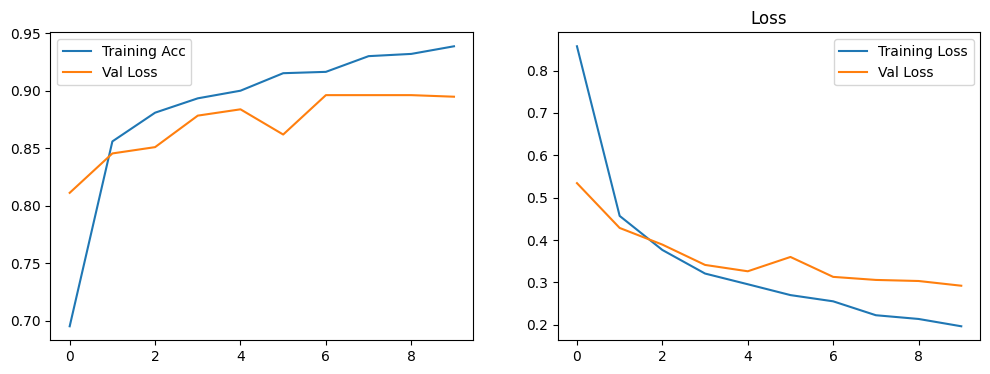

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Acc')
plt.plot(history.history['val_accuracy'], label='Val Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [12]:
loss, acc = model.evaluate(test_generator)
print("Test Accuracy: , {acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.8790 - loss: 0.3113
Test Accuracy: , {acc:.4f}


In [19]:
from tensorflow.keras.preprocessing import image
def predict_image(img_path):
  img=image.load_img(img_path,target_size=IMG_SIZE)
  img_array=image.img_to_array(img)
  img_array=preprocess_input(img_array)
  img_array=np.expand_dims(img_array,axis=0)
  preds=model.predict(img_array)
  class_index = np.argmax(preds)
  class_label = list(train_generator.class_indices.keys())[class_index]
  print(f"Prediction :{class_label}({preds[0][class_index]*100:.2f}%)")

  plt.imshow(img)
  plt.axis('off')
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction :dandelion(99.95%)


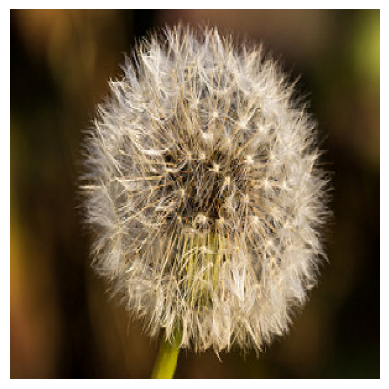

In [20]:
predict_image("/content/flowers_split/test/dandelion/10486992895_20b344ce2d_n.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction :dandelion(89.76%)


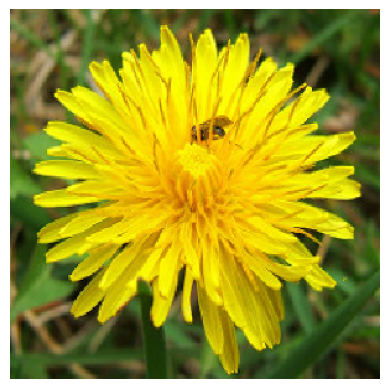

In [21]:
predict_image("/content/flowers_split/test/dandelion/141935731_d26d600f4f_m.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Prediction :tulips(52.99%)


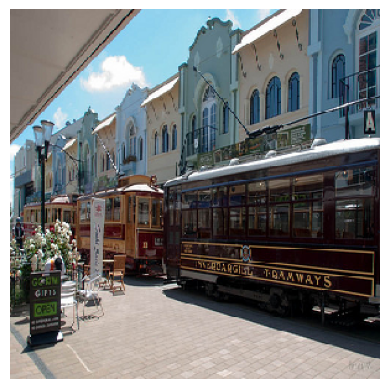

In [22]:
predict_image("/content/flowers_split/test/roses/12450781274_eb78723921.jpg")